In [1]:
# sucht that we can import our custom modules
import sys
import os
sys.path.append(os.path.abspath('../'))

## Graph Generation

In [2]:
from lib.graph_generator import GraphGenerator
from lib.utils import plot_graph, drop_pair

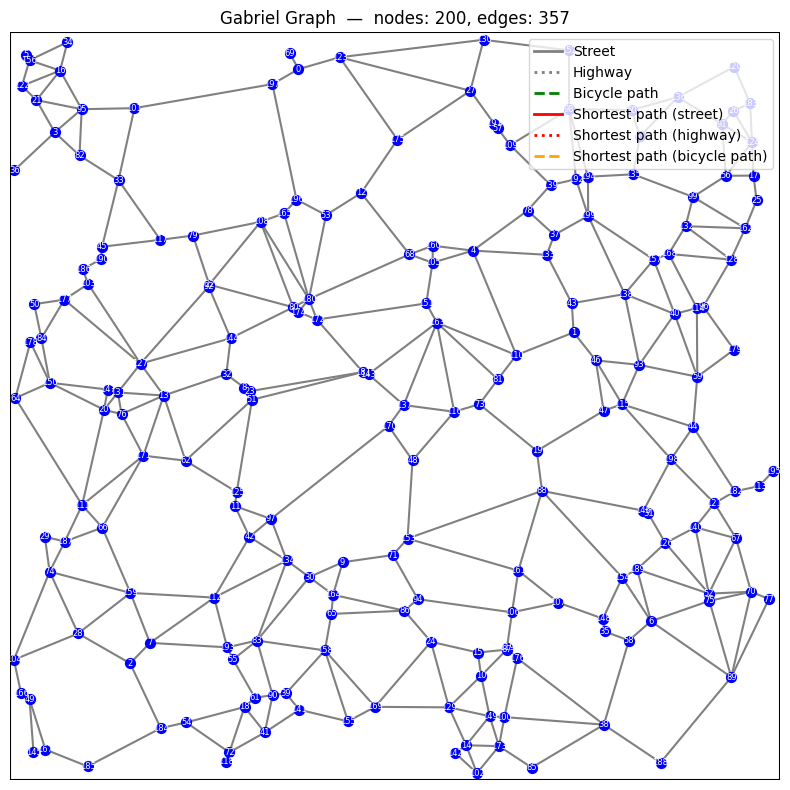

In [3]:
NUMBER_OF_NODES = 200

graph_gen = GraphGenerator(NUMBER_OF_NODES, seed=42)
GG = graph_gen.gabriel_graph()
plot_graph(GG, title="Gabriel Graph")

In [4]:
print("Example Edges and edge features:\n")
for u, v in list(GG.edges)[10:13]:
    print(f"Edge: {u} -> {v}:")
    print(f"\tDistance: {GG[u][v]['distance']}")

sum_distance = 0
sum_speed = 0
sum_duration = 0
num_edges = 0
for u, v in GG.edges:
    num_edges += 1
    sum_distance += GG[u][v]["distance"]
print(f"Average Distance: {sum_distance / num_edges}")

Example Edges and edge features:

Edge: 3 -> 36:
	Distance: 0.07303898489287045
Edge: 3 -> 82:
	Distance: 0.044614110789975556
Edge: 3 -> 95:
	Distance: 0.04679528593525627
Average Distance: 0.06697776446716595


## Graph Preprocessing

In [5]:
import torch
from torch_geometric.data import Data

/opt/homebrew/Caskroom/miniconda/base/envs/AML/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
import torch
from torch_geometric.data import Data

In [7]:
import lib.graph_preprocessor
from lib.graph_preprocessor import GraphPreprocessor

In [8]:
graph_preprocessor = GraphPreprocessor(GG)
pyg_data = graph_preprocessor.create_pyg_data()

adjacency = graph_preprocessor.adjacency_from_nx()
distance_matrix = graph_preprocessor.distance_matrix_from_nx()

Edge attr shape: torch.Size([1114, 1])


In [9]:
from itertools import permutations, combinations
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split
import networkx as nx

In [10]:
def all_shortest_path_instances(G, drop_short_paths=True):
    instances = []
    for s, t in combinations(G.nodes, 2):  # for s, t in permutations(G.nodes, 2) for both directions
        shortest_distance_path = None
        shortest_distance_path = nx.dijkstra_path(G, s, t, weight="distance")
        
        if drop_pair(shortest_distance_path, len(G.nodes)):
            shortest_distance_path = None

        if (shortest_distance_path != None):
            instances.append(
                {
                    "source": s,
                    "target": t,
                    "distance_path": shortest_distance_path,
                    "adjacency_matrix": graph_preprocessor.adjacency_from_nx(),
                    "distance_matrix": graph_preprocessor.distance_matrix_from_nx(),
                }
            )
    return instances

In [11]:
graph_preprocessor = GraphPreprocessor(GG)
pyg_data = graph_preprocessor.create_pyg_data()
pyg_data

Edge attr shape: torch.Size([1114, 1])


Data(x=[201, 3], edge_index=[2, 1114], edge_attr=[1114, 1])

In [12]:
pairs = all_shortest_path_instances(GG, drop_short_paths=True)
print(f"Number of pairs: {len(pairs)}")

Number of pairs: 17104


In [13]:
def create_instances(pairs, pyg_data):
    instances = []

    for p in pairs:
        instances.append(
            {
                "graph": pyg_data,
                "source": p["source"],
                "target": p["target"],
                "distance_path": p["distance_path"],
                "adjacency_matrix": p["adjacency_matrix"],
                "distance_matrix": p["distance_matrix"]
            }
        )
    return instances


instances = create_instances(pairs, pyg_data)
max_len = max(len(instance.get("distance_path") or []) for instance in instances)


train_instances, temp_instances = train_test_split(
    instances, test_size=0.3, random_state=50, shuffle=True
)
val_instances, test_instances = train_test_split(
    temp_instances, test_size=0.5, random_state=50, shuffle=True
)

combined_train_instances = (
    train_instances + val_instances
)  # To train model on all data except test_instances

In [14]:
from lib.shortest_path_dataset import ShortestPathDataset

dataset = ShortestPathDataset(
    train_instances, max_len=max_len, include_target_and_source=False
)
val_dataset = ShortestPathDataset(
    val_instances, max_len=max_len, include_target_and_source=False
)
test_dataset = ShortestPathDataset(
    test_instances, max_len=max_len, include_target_and_source=False
)
combined_train_dataset = ShortestPathDataset(
    combined_train_instances, max_len=max_len, include_target_and_source=False
)

tokenizer = dataset.tokenizer

sample = dataset[2]
print("Graph:", sample["graph"])
print("Source Node:", sample["source"].item())
print("Target Node:", sample["target"].item())
print()

print("Shortest Distance path:", sample["distance_path"].tolist())
decoded_path = dataset.tokenizer.decode(sample["distance_path"].tolist())
print("Shortest Distance path (decoded):", decoded_path)
print()

Graph: Data(x=[201, 3], edge_index=[2, 1114], edge_attr=[1114, 1])
Source Node: 57
Target Node: 59

Shortest Distance path: [204, 201, 109, 139, 192, 199, 157, 40, 203, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202, 202]
Shortest Distance path (decoded): ['<DIST>', '<BOS>', 109, 139, 192, 199, 157, 40, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



In [15]:
from lib.augment_data_helpers import augment_with_reversed
augmented_dataset = augment_with_reversed(dataset, debug=False)
print(f"Original dataset size: {len(dataset)}")
print(f"Augmented dataset size: {len(augmented_dataset)}")

augment_combined_dataset = augment_with_reversed(combined_train_dataset)

Original dataset size: 11972
Augmented dataset size: 23944


In [16]:
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch

In [17]:
train_loader = DataLoader(augmented_dataset, batch_size=16, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
combined_train_loader = DataLoader(combined_train_dataset, batch_size=16, shuffle=False)

In [18]:
print("Number of instances:", len(augmented_dataset))
print("Number of batches:", len(train_loader))

Number of instances: 23944
Number of batches: 1497


In [19]:
import torch
from torch import nn
from torch_geometric.nn import GCNConv


class NextHopGNN(nn.Module):
    def __init__(self, in_dim, hid_dim, num_nodes):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hid_dim)
        self.conv2 = GCNConv(hid_dim, hid_dim)
        self.mlp = nn.Sequential(
            nn.Linear(2 * hid_dim, hid_dim), nn.ReLU(), nn.Linear(hid_dim, num_nodes)
        )

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = torch.relu(h)
        h = self.conv2(h, edge_index)
        return h

In [20]:
from torch_geometric.nn import SAGEConv
import torch.nn as nn
import torch


class NextHopGNNv2(nn.Module):
    def __init__(self, in_dim, hid_dim, num_nodes):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hid_dim)
        self.conv2 = SAGEConv(hid_dim, hid_dim)
        self.norm = nn.LayerNorm(hid_dim)
        self.mlp = nn.Sequential(
            nn.Linear(2 * hid_dim, hid_dim), nn.ReLU(), nn.Linear(hid_dim, num_nodes)
        )

    def forward(self, x, edge_index):
        h1 = torch.relu(self.conv1(x, edge_index))
        h2 = torch.relu(self.conv2(h1, edge_index))
        h = self.norm(h1 + h2)
        return h

In [21]:
import torch
from torch import nn
from torch_geometric.nn import SAGEConv


class HybridNextHopGNN(nn.Module):
    def __init__(self, in_dim, hid_dim, num_nodes, num_heads=4):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hid_dim)
        self.conv2 = SAGEConv(hid_dim, hid_dim)
        self.gnn_norm = nn.LayerNorm(hid_dim)
        self.attn = nn.MultiheadAttention(hid_dim, num_heads)
        self.attn_norm = nn.LayerNorm(hid_dim)
        self.mlp = nn.Sequential(
            nn.Linear(2 * hid_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, num_nodes),
        )

    def encode(self, x, edge_index):
        h1 = torch.relu(self.conv1(x, edge_index))
        h2 = torch.relu(self.conv2(h1, edge_index))
        h = self.gnn_norm(h1 + h2)
        return h

    def forward(self, x, edge_index):
        h = self.encode(x, edge_index)
        h_seq = h.unsqueeze(1)
        h_attn, _ = self.attn(h_seq, h_seq, h_seq)
        h_out = self.attn_norm(h_seq + h_attn)
        return h_out.squeeze(1)

In [22]:
class NextHopGNNv3(nn.Module):
    def __init__(self, in_dim, hid_dim, num_nodes):
        super().__init__()
        self.emb_in = nn.Linear(in_dim, hid_dim)

        self.conv1 = SAGEConv(hid_dim * 2, hid_dim)
        self.conv2 = SAGEConv(hid_dim * 2, hid_dim)

        self.norm = nn.LayerNorm(hid_dim)

        self.mlp = nn.Sequential(
            nn.Linear(2 * hid_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, num_nodes),
        )

    def forward(self, x, edge_index, target_node):
        h0 = self.emb_in(x)
        target_emb = h0[target_node]

        T = target_emb.expand(h0.size(0), -1)
        h1 = torch.relu(self.conv1(torch.cat([h0, T], dim=-1), edge_index))

        T = target_emb.expand(h1.size(0), -1)
        h2 = torch.relu(self.conv2(torch.cat([h1, T], dim=-1), edge_index))

        return self.norm(h2)

In [23]:
class HybridNextHopTargetAware(nn.Module):
    def __init__(self, in_dim, hid_dim, num_nodes, num_heads=4):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hid_dim)
        self.conv2 = SAGEConv(hid_dim, hid_dim)
        self.gnn_norm = nn.LayerNorm(hid_dim)
        self.attn = nn.MultiheadAttention(hid_dim, num_heads)
        self.mlp = nn.Sequential(
            nn.Linear(3 * hid_dim, hid_dim),
            nn.ReLU(),
            nn.Linear(hid_dim, num_nodes),
        )

    def encode(self, x, edge_index):
        h1 = torch.relu(self.conv1(x, edge_index))
        h2 = torch.relu(self.conv2(h1, edge_index))
        return self.gnn_norm(h1 + h2)

    def forward(self, x, edge_index):
        return self.encode(x, edge_index)

    def logits_for_graph(self, h, target_node):
        h_seq = h.unsqueeze(1)
        q = h[target_node].unsqueeze(0).unsqueeze(1)
        ctx, _ = self.attn(q, h_seq, h_seq)
        ctx = ctx.squeeze(1).repeat(h.size(0), 1)
        cur = h
        tgt = h[target_node].repeat(h.size(0), 1)
        logits = self.mlp(torch.cat([cur, tgt, ctx], dim=-1))
        return logits

In [24]:
def extract_path(seq, eos_id):
    out = []
    for t in seq[2:]:
        if t == eos_id:
            break
        out.append(int(t))
    return out

In [25]:
@torch.no_grad()
def evaluate(model, loader, eos_id, device):
    model.eval()
    ce = nn.CrossEntropyLoss()
    total = 0
    count = 0

    for batch in loader:
        graphs = batch["graph"].to(device)
        paths = batch["distance_path"]

        h = model(graphs.x, graphs.edge_index)

        for i in range(graphs.num_graphs):
            mask = graphs.batch == i
            node_emb = h[mask]

            seq = paths[i].tolist()
            path = extract_path(seq, eos_id)

            for j in range(len(path) - 1):
                cur_node = path[j]
                next_node = path[j + 1]

                logits = model.mlp(torch.cat([node_emb[cur_node], node_emb[path[-1]]]))
                target_node = torch.tensor([next_node], device=device)

                total += ce(logits.unsqueeze(0), target_node).item()
                count += 1

    return total / max(1, count)

In [26]:
def train_epoch(model, loader, optimizer, eos_id, device):
    model.train()
    total_loss = 0
    ce = nn.CrossEntropyLoss()

    for batch in loader:
        graphs = batch["graph"].to(device)
        paths = batch["distance_path"]

        loss = 0
        count = 0

        for i in range(graphs.num_graphs):
            g = graphs.get_example(i)
            x = g.x
            edge_index = g.edge_index

            seq = paths[i].tolist()
            true_path = extract_path(seq, eos_id)
            target_node = true_path[-1]

            h = model(x, edge_index)

            for j in range(len(true_path) - 1):
                cur = true_path[j]
                nxt = true_path[j + 1]

                logits = model.mlp(torch.cat([h[cur], h[target_node]]))
                loss += ce(logits.unsqueeze(0), torch.tensor([nxt], device=device))
                count += 1

        loss = loss / max(1, count)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

In [27]:
from torch_geometric.utils import subgraph


def extract_graph(graphs, idx):
    mask = graphs.batch == idx
    node_ids = mask.nonzero(as_tuple=False).view(-1)

    edge_index, _ = subgraph(node_ids, graphs.edge_index, relabel_nodes=True)
    x = graphs.x[node_ids]
    return x, edge_index


def train_epoch(model, loader, optimizer, eos_id, device):
    model.train()
    ce = nn.CrossEntropyLoss()
    total = 0

    for batch in loader:
        graphs = batch["graph"].to(device)
        paths = batch["distance_path"]

        loss = 0
        count = 0

        for i in range(graphs.num_graphs):
            x, edge_index = extract_graph(graphs, i)
            seq = paths[i].tolist()

            path = extract_path(seq, eos_id)
            target_node = path[-1]

            # h = model(x, edge_index, target_node)
            h = model(x, edge_index)

            for j in range(len(path) - 1):
                cur = path[j]
                nxt = path[j + 1]

                # logits = model.mlp(torch.cat([h[cur], h[target_node]]))

                logits_all = model.logits_for_graph(h, target_node)
                logits = logits_all[cur]

                loss += ce(logits.unsqueeze(0), torch.tensor([nxt], device=device))
                count += 1

        loss = loss / max(1, count)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    return total / len(loader)

In [28]:
@torch.no_grad()
def evaluate(model, loader, eos_id, device):
    model.eval()
    ce = nn.CrossEntropyLoss()

    total_loss = 0
    total_count = 0

    for batch in loader:
        graphs = batch["graph"].to(device)
        paths = batch["distance_path"]

        batch_loss = 0
        batch_count = 0

        for i in range(graphs.num_graphs):
            x, edge_index = extract_graph(graphs, i)

            seq = paths[i].tolist()
            path = extract_path(seq, eos_id)
            target_node = path[-1]

            # h = model(x, edge_index, target_node)
            h = model(x, edge_index)

            for j in range(len(path) - 1):
                cur = path[j]
                nxt = path[j + 1]

                # logits = model.mlp(torch.cat([h[cur], h[target_node]]))

                logits_all = model.logits_for_graph(h, target_node)
                logits = logits_all[cur]
                batch_loss += ce(
                    logits.unsqueeze(0), torch.tensor([nxt], device=device)
                ).item()
                batch_count += 1

        total_loss += batch_loss / max(1, batch_count)
        total_count += 1

    return total_loss / max(1, total_count)

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

in_dim = dataset[0]["graph"].x.size(1)
num_nodes = dataset[0]["graph"].x.size(0)
eos_id = dataset.tokenizer.special_tokens["<EOS>"]

# model = NextHopGNN(in_dim, 64, num_nodes).to(device)
# model = NextHopGNN(in_dim, 128, num_nodes)
# model = NextHopGNN(in_dim, 256, num_nodes)
# model = NextHopGNNv2(in_dim, 128, num_nodes).to(device)
# model = NextHopGNNv3(in_dim, 128, num_nodes).to(device)
# model = HybridNextHopGNN(in_dim, 128, num_nodes, num_heads=4).to(device)
model = HybridNextHopTargetAware(in_dim, 128, num_nodes, num_heads=4).to(device)


opt = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(20):
    loss = train_epoch(model, train_loader, opt, eos_id, device)
    val = evaluate(model, val_loader, eos_id, device)
    print(epoch, loss, val)

0 1.5639704386233966 0.7190763133847655
1 0.5250785837849539 0.31838222174690123
2 0.28360815145667584 0.1929588232675622
3 0.19436266589300108 0.13068274028766094
4 0.1459006105656017 0.13267826403814761
5 0.12054608047068238 0.10139113259314508
6 0.09423668590749433 0.07399785859857208
7 0.0892992524396561 0.06657864176618991
8 0.07357159145232402 0.07762428246457236
9 0.08053448672686954 0.05243957636829686
10 0.05369510713752556 0.05275065990563521
11 0.05162925522994691 0.07986865657387782
12 0.04918220887449306 0.04284069964289076
13 0.04832402485649555 0.034701165083987615
14 0.04408680491963477 0.040912460321226994
15 0.03534273395554953 0.022568371164787767
16 0.03978520622481602 0.022345631788112868
17 0.03414436202402505 0.039028534468805366
18 0.029544448472855585 0.02806991291525466
19 0.03072221794522771 0.0604251573702413


In [30]:
@torch.no_grad()
def next_hop_accuracy(model, loader, eos_id, device):
    model.eval()
    correct = 0
    total = 0

    for batch in loader:
        graphs = batch["graph"].to(device)
        paths = batch["distance_path"]
        h = model(graphs.x, graphs.edge_index)

        for i in range(graphs.num_graphs):
            mask = graphs.batch == i
            node_emb = h[mask]

            seq = paths[i].tolist()
            path = extract_path(seq, eos_id)

            for j in range(len(path) - 1):
                cur_node = path[j]
                next_node = path[j + 1]

                logits = model.mlp(torch.cat([node_emb[cur_node], node_emb[path[-1]]]))

                pred = logits.argmax().item()
                if pred == next_node:
                    correct += 1
                total += 1

    return correct / max(1, total)

In [31]:
@torch.no_grad()
def next_hop_accuracy(model, loader, eos_id, device):
    model.eval()
    correct = 0
    total = 0

    for batch in loader:
        graphs = batch["graph"].to(device)
        paths = batch["distance_path"]

        for i in range(graphs.num_graphs):
            x, edge_index = extract_graph(graphs, i)

            seq = paths[i].tolist()
            path = extract_path(seq, eos_id)
            target_node = path[-1]

            # h = model(x, edge_index, target_node)
            h = model(x, edge_index)

            for j in range(len(path) - 1):
                cur = path[j]
                nxt = path[j + 1]

                # logits = model.mlp(torch.cat([h[cur], h[target_node]]))

                logits_all = model.logits_for_graph(h, target_node)
                logits = logits_all[cur]
                pred = logits.argmax().item()

                correct += int(pred == nxt)
                total += 1

    return correct / max(1, total)

In [32]:
# Next-hop accuracy: 0.7281132620629875
# Rollout: 0.17343173431734318
# Reachability: 0.32287822878228783

# Next-hop accuracy: 0.8390638543773475
# Rollout: 0.39114391143911437

# Next-hop accuracy: 0.8826928633342964
# Rollout: 0.48523985239852396

# Next-hop accuracy: 0.9945102571511124
# Rollout: 0.9649446494464945
# Reachability: 0.996309963099631

# Next-hop accuracy: 0.9673504767408263
# Rollout: 0.8154981549815498
# Reachability: 0.9077490774907749

# Next-hop accuracy: 0.9982663969950881
# Rollout: 0.988929889298893
# Reachability: 1.0

# Next-hop accuracy: 0.9930655879803525
# Rollout: 0.9575645756457565
#Reachability: 0.9723247232472325

In [33]:
acc = next_hop_accuracy(model, test_loader, eos_id, device)
print("Next-hop accuracy:", acc)

Next-hop accuracy: 0.9800059683676514


In [34]:
@torch.no_grad()
def rollout_accuracy(model, loader, eos_id, device, max_steps=50):
    model.eval()
    correct_paths = 0
    total_paths = 0

    for batch in loader:
        graphs = batch["graph"].to(device)
        paths = batch["distance_path"]
        h = model(graphs.x, graphs.edge_index)

        for i in range(graphs.num_graphs):
            mask = graphs.batch == i
            node_emb = h[mask]

            seq = paths[i].tolist()
            true_path = extract_path(seq, eos_id)
            target = true_path[-1]
            current = true_path[0]

            predicted = [current]

            for _ in range(max_steps):
                logits = model.mlp(torch.cat([node_emb[current], node_emb[target]]))
                next_node = logits.argmax().item()
                predicted.append(next_node)
                current = next_node
                if current == target:
                    break

            if predicted == true_path:
                correct_paths += 1
            total_paths += 1

    return correct_paths / max(1, total_paths)

In [35]:
@torch.no_grad()
def rollout_accuracy(model, loader, eos_id, device, max_steps=50):
    model.eval()
    correct_paths = 0
    total_paths = 0

    for batch in loader:
        graphs = batch["graph"].to(device)
        paths = batch["distance_path"]

        for i in range(graphs.num_graphs):
            x, edge_index = extract_graph(graphs, i)

            seq = paths[i].tolist()
            true_path = extract_path(seq, eos_id)

            target = true_path[-1]
            current = true_path[0]

            # h = model(x, edge_index, target)
            h = model(x, edge_index)

            predicted = [current]

            for _ in range(max_steps):
                # logits = model.mlp(torch.cat([h[current], h[target]]))
                logits_all = model.logits_for_graph(h, target)
                logits = logits_all[current]
                next_node = logits.argmax().item()

                predicted.append(next_node)
                current = next_node

                if current == target:
                    break

            if predicted == true_path:
                correct_paths += 1

            total_paths += 1

    return correct_paths / max(1, total_paths)

In [36]:
rollout_acc = rollout_accuracy(model, test_loader, eos_id, device)
print("Rollout:", rollout_acc)

Rollout: 0.8472330475448169


In [37]:
@torch.no_grad()
def reachability_accuracy(model, loader, eos_id, device, max_steps=50):
    model.eval()
    success = 0
    total = 0

    for batch in loader:
        graphs = batch["graph"].to(device)
        paths = batch["distance_path"]
        h = model(graphs.x, graphs.edge_index)

        for i in range(graphs.num_graphs):
            mask = graphs.batch == i
            node_emb = h[mask]

            seq = paths[i].tolist()
            true_path = extract_path(seq, eos_id)
            target = true_path[-1]
            current = true_path[0]

            for _ in range(max_steps):
                logits = model.mlp(torch.cat([node_emb[current], node_emb[target]]))
                next_node = logits.argmax().item()
                current = next_node
                if current == target:
                    success += 1
                    break

            total += 1

    return success / max(1, total)

In [38]:
@torch.no_grad()
def reachability_accuracy(model, loader, eos_id, device, max_steps=50):
    model.eval()
    success = 0
    total = 0

    for batch in loader:
        graphs = batch["graph"].to(device)
        paths = batch["distance_path"]

        for i in range(graphs.num_graphs):
            x, edge_index = extract_graph(graphs, i)

            seq = paths[i].tolist()
            true_path = extract_path(seq, eos_id)
            target = true_path[-1]
            current = true_path[0]

            # h = model(x, edge_index, target)
            h = model(x, edge_index)

            for _ in range(max_steps):
                # logits = model.mlp(torch.cat([h[current], h[target]]))
                logits_all = model.logits_for_graph(h, target)
                logits = logits_all[current]
                next_node = logits.argmax().item()
                current = next_node

                if current == target:
                    success += 1
                    break

            total += 1

    return success / max(1, total)

In [39]:
reachability_acc = reachability_accuracy(model, test_loader, eos_id, device)
print("Reachability:", reachability_acc)

Reachability: 0.9232268121590024


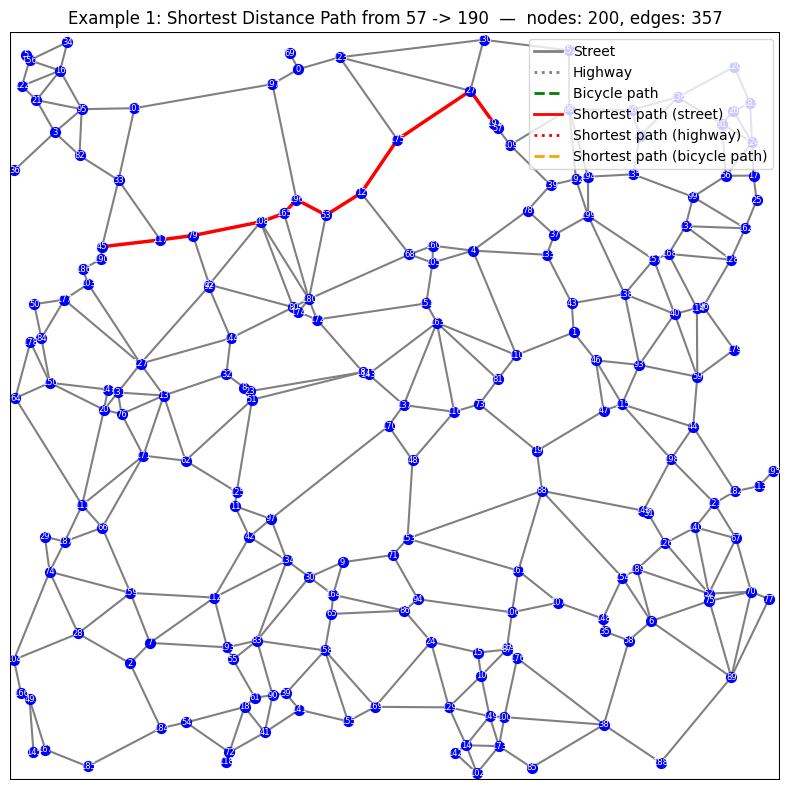

Source: 57, target: 190
Distance: ['<DIST>', '<BOS>', 191, 27, 175, 12, 53, 196, 165, 108, 79, 117, 45, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



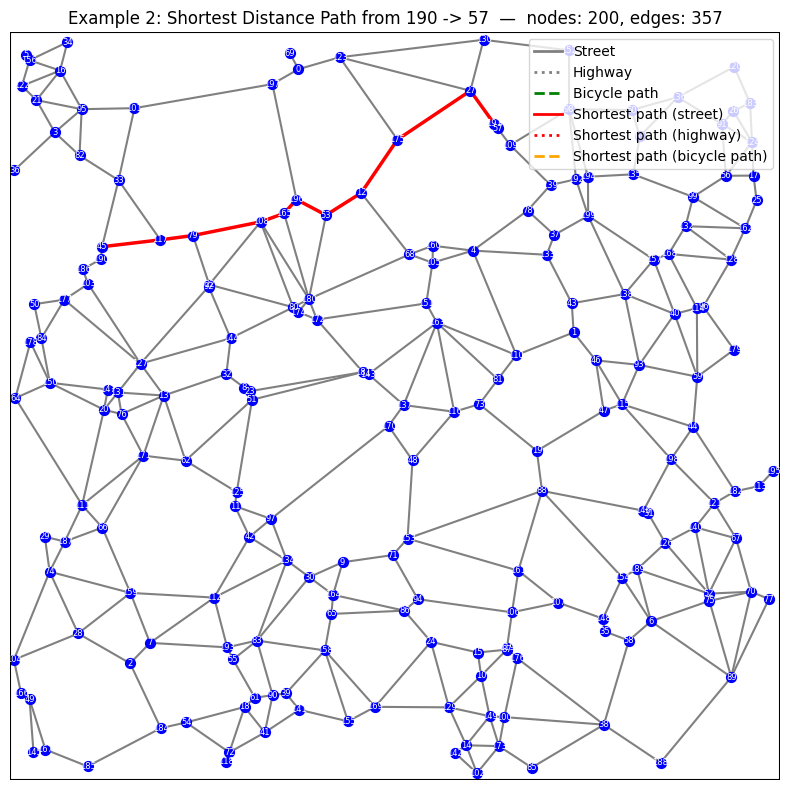

Source: 190, target: 57
Distance: ['<DIST>', '<BOS>', 45, 117, 79, 108, 165, 196, 53, 12, 175, 27, 191, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



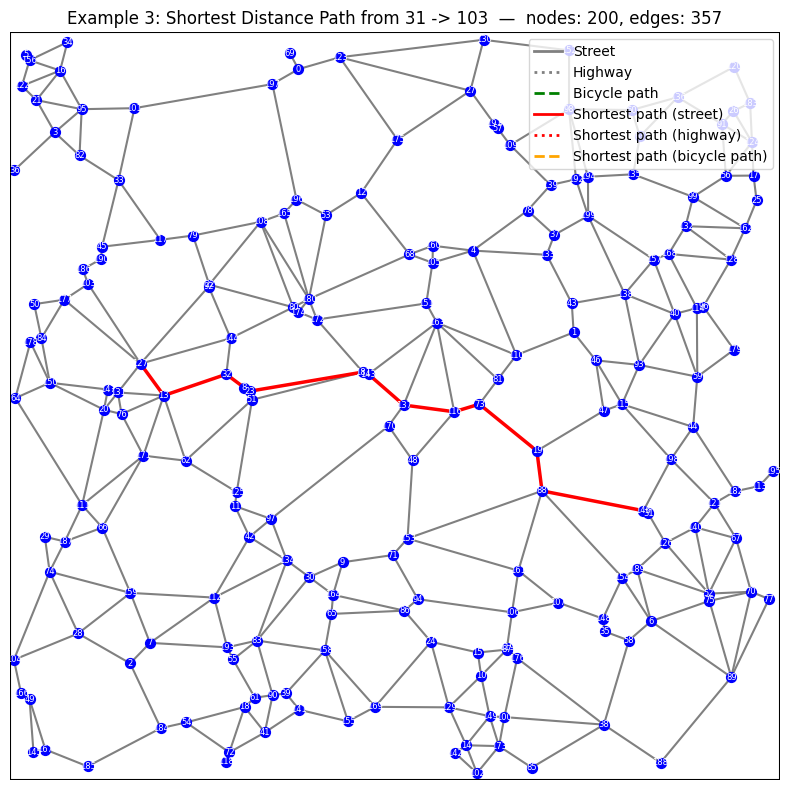

Source: 31, target: 103
Distance: ['<DIST>', '<BOS>', 146, 88, 19, 73, 116, 137, 143, 181, 23, 8, 32, 13, 127, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



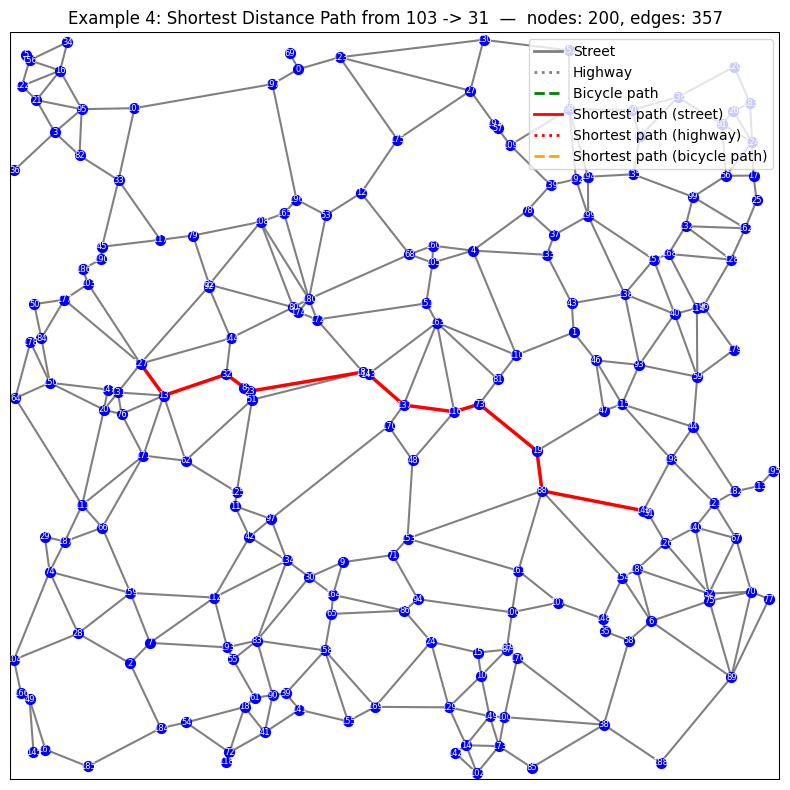

Source: 103, target: 31
Distance: ['<DIST>', '<BOS>', 127, 13, 32, 8, 23, 181, 143, 137, 116, 73, 19, 88, 146, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



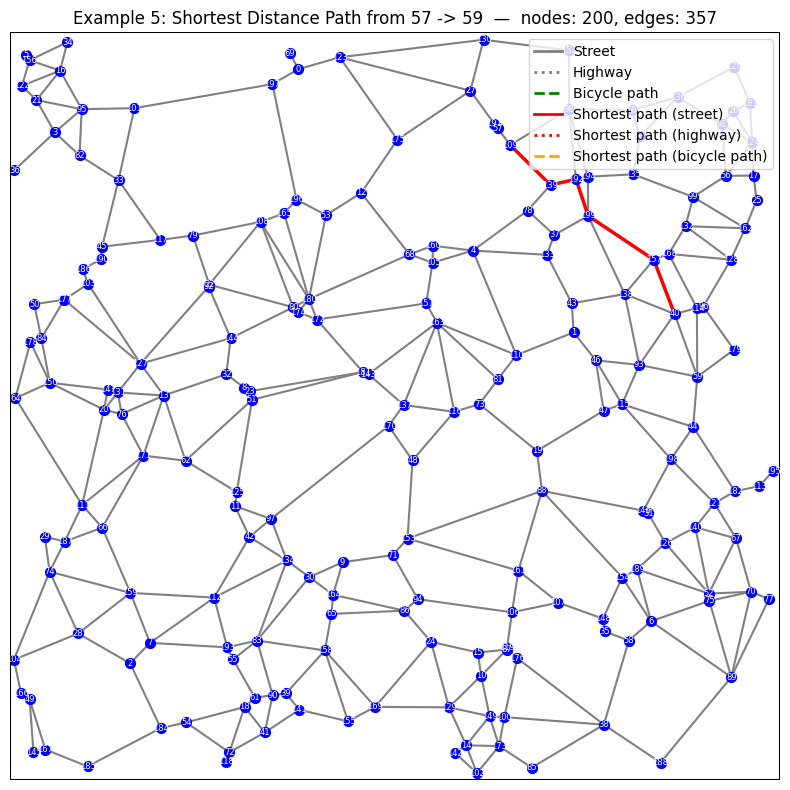

Source: 57, target: 59
Distance: ['<DIST>', '<BOS>', 109, 139, 192, 199, 157, 40, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



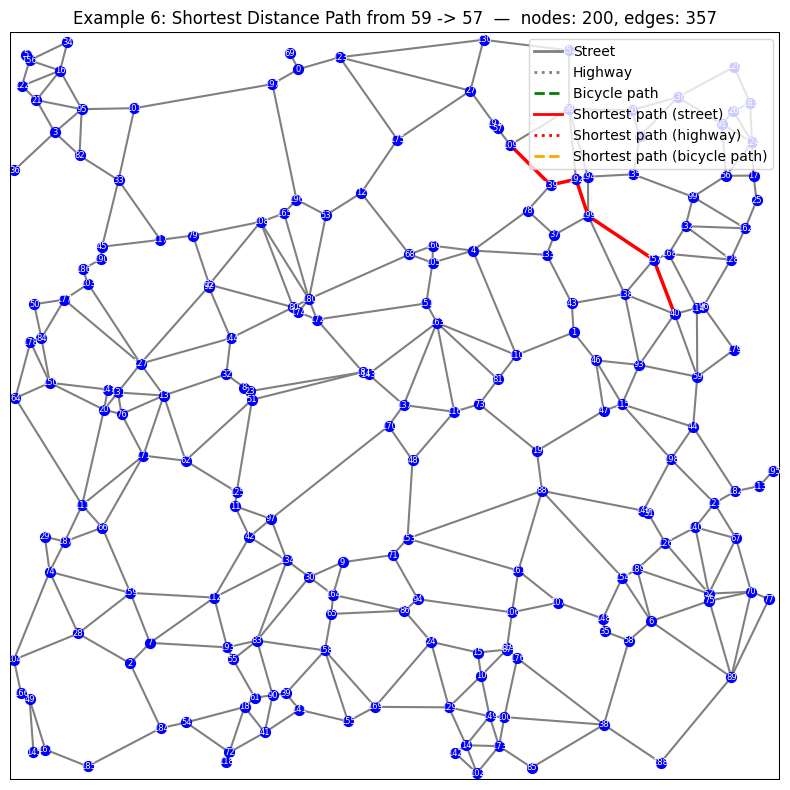

Source: 59, target: 57
Distance: ['<DIST>', '<BOS>', 40, 157, 199, 192, 139, 109, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



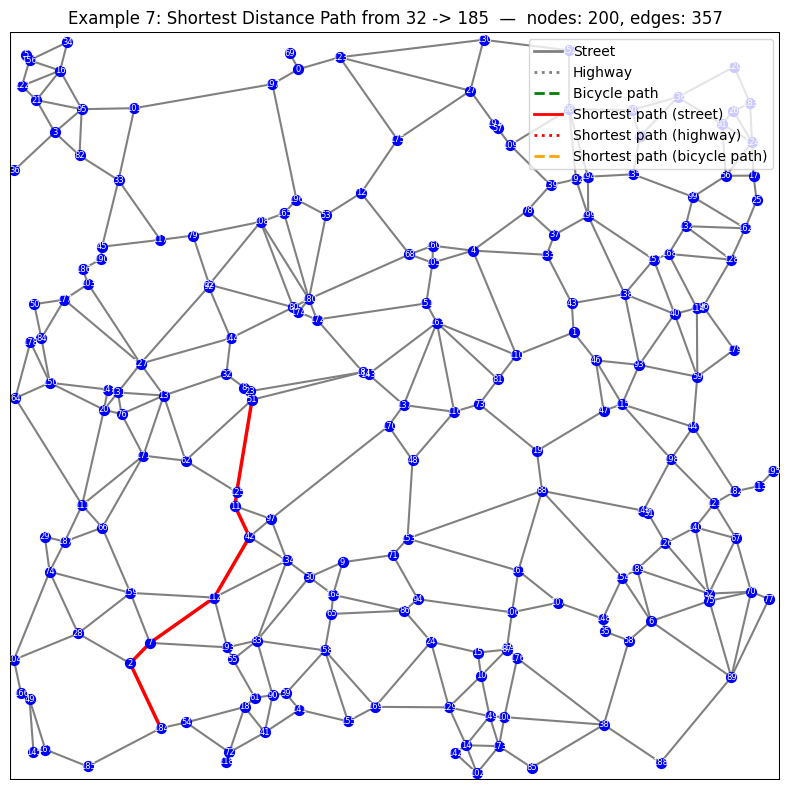

Source: 32, target: 185
Distance: ['<DIST>', '<BOS>', 8, 23, 51, 125, 11, 42, 112, 7, 2, 184, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']



In [40]:
for i in range(len(augmented_dataset)):
    shortest_distance_path = dataset.get_decoded_path(
        augmented_dataset[i]["distance_path"]
    )
    source = augmented_dataset[i]["source"]
    target = augmented_dataset[i]["target"]

    plot_graph(
        GG,
        shortest_distance_path,
        f"Example {i+1}: Shortest Distance Path from {source} -> {target}",
    )

    print(
        f"Source: {augmented_dataset[i]['source']}, target: {augmented_dataset[i]['target']}"
    )
    print(
        f"Distance: {dataset.get_decoded_path(augmented_dataset[i]['distance_path'])}"
    )
    print()
    if i > 5:
        break

In [41]:
from lib.model_gnn import ShortestPathGNN

data = pyg_data
print("x:", data.x.shape)
print("edge_index:", data.edge_index.shape)
print("edge_attr:", data.edge_attr.shape)

model_encoder = ShortestPathGNN(in_dim=3, hidden_dim=16, edge_attr_dim=1)

out = model_encoder(data.x, data.edge_index, data.edge_attr)
print("Output shape:", out.shape)

x: torch.Size([201, 3])
edge_index: torch.Size([2, 1114])
edge_attr: torch.Size([1114, 1])
Output shape: torch.Size([201, 16])


In [42]:
def mask_out_invalid_next_hops(
    adjacency_matrix, decoder_model, last_token, logits_step
):
    if adjacency_matrix is None:
        return logits_step

    if 0 <= last_token < adjacency.size(0):
        valid_next = adjacency_matrix[last_token]
        masked_logits = torch.full_like(logits_step, float("-inf"))
        masked_logits[: valid_next.size(0)] = valid_next.float().log()

        masked_logits[decoder_model.eos_idx] = 0.0  # allow <eos>
        logits_step = logits_step + masked_logits
    else:
        logits_step[decoder_model.eos_idx] = logits_step[decoder_model.eos_idx] + 0.0

    return logits_step

In [43]:
def beam_search(
    gnn_model,
    decoder_model,
    graph,
    start_node,
    goal_node,
    padding_idx,
    beam_width=3,
    max_len=16,
    adjacency_matrix=None,
    criterion=None,
):
    device = next(gnn_model.parameters()).device
    graph = graph.to(device)
    x = graph.x
    edge_index = graph.edge_index
    edge_attr = graph.edge_attr

    criterion_token = (
        decoder_model.criterion_tokens[criterion] if criterion is not None else None
    )  # '<DIST>' if criterion == 'distance' else '<DUR>'
    token_ids = [
        decoder_model.padding_idx,
        decoder_model.bos_idx,
        decoder_model.eos_idx,
    ] + list(decoder_model.criterion_tokens.values())
    node_embeddings = gnn_model(x, edge_index, edge_attr)
    memory = node_embeddings.unsqueeze(0).expand(1, -1, -1)  # batch_size = 1

    if criterion_token is None:
        generated = [decoder_model.bos_idx]
    else:
        generated = [criterion_token, decoder_model.bos_idx]

    start_node = torch.tensor([start_node], device=device)
    goal_node = torch.tensor([goal_node], device=device)

    sequences = [(generated, 0, 0)]  # (sequence, score, distance)

    for step in range(max_len):
        all_candidates = []

        for seq, score, distance in sequences:
            if seq[-1] == decoder_model.eos_idx or seq[-1] == padding_idx:
                all_candidates.append((seq, score, distance))
                continue

            next_hop_logits = decoder_model(
                torch.tensor([seq], dtype=torch.long, device=memory.device),
                memory=memory,
                start_node=start_node,
                goal_node=goal_node,
            )[0, -1]

            next_hop_logits = mask_out_invalid_next_hops(
                adjacency_matrix, decoder_model, seq[-1], next_hop_logits
            )

            next_token_probs = torch.softmax(next_hop_logits, dim=-1)
            topk_probs, topk_indices = torch.topk(next_token_probs, k=beam_width)

            for prob, hop in zip(topk_probs, topk_indices):
                if (
                    (not seq[-1] in token_ids)
                    and (not hop.item() in token_ids)
                    and (adjacency_matrix is not None)
                    and (criterion is not None)
                ):
                    if GG.get_edge_data(seq[-1], hop.item()) is None:
                        tmp_distance = 0
                    else:
                        edge_attr_key = (
                            "duration" if criterion == "duration" else "distance"
                        )
                        if criterion in ["car_distance", "bike_distance"]:
                            edge_attr_key = "distance"
                        elif criterion in ["car_duration", "bike_duration"]:
                            edge_attr_key = "duration"
                        tmp_distance = GG.get_edge_data(seq[-1], hop.item())[
                            edge_attr_key
                        ]
                else:
                    tmp_distance = 0
                candidate = (
                    seq + [hop.item()],
                    score - prob.log().item(),
                    distance + tmp_distance,
                )
                all_candidates.append(candidate)

        all_candidates = sorted(all_candidates, key=lambda tup: tup[1])
        sequences = all_candidates[:beam_width]

    return sequences[0]  # return the best sequence

In [44]:
def greedy_decode(
    gnn_model,
    decoder_model,
    graph,
    start_node,
    goal_node,
    padding_idx,
    max_len=16,
    adjacency_matrix=None,
    criterion=None,
):
    device = next(gnn_model.parameters()).device
    graph = graph.to(device)
    x = graph.x
    edge_index = graph.edge_index
    edge_attr = graph.edge_attr

    criterion_token = decoder_model.criterion_tokens[criterion] or None
    node_embeddings = gnn_model(x, edge_index, edge_attr)  # [num_nodes, embeda_dim]
    memory = node_embeddings.unsqueeze(0).expand(1, -1, -1)  # [1, num_nodes, embed_dim]

    if criterion_token is None:
        generated = [decoder_model.bos_idx]
    else:
        generated = [criterion_token, decoder_model.bos_idx]

    start_node = torch.tensor([start_node], device=device)
    goal_node = torch.tensor([goal_node], device=device)

    for _ in range(max_len - 1):
        input_seq = torch.tensor([generated], dtype=torch.long, device=device)  # [1, t]
        tgt_mask = decoder_model.generate_square_subsequent_mask(input_seq.size(1))

        logits = decoder_model(
            input_seq,
            memory=memory,
            tgt_mask=tgt_mask,
            start_node=start_node,
            goal_node=goal_node,
        )  # [1, t, vocab_size]

        last_token = generated[-1]
        logits_step = logits[0, -1]  # [vocab_size]

        if last_token == decoder_model.bos_idx:
            last_token = start_node.item()

        # Mask invalid nodes based on the adjacency matrix
        logits_step = mask_out_invalid_next_hops(
            adjacency_matrix, decoder_model, last_token, logits_step
        )
        next_token = logits_step.argmax().item()

        if next_token == decoder_model.eos_idx or next_token == padding_idx:
            break

        generated.append(next_token)

    return generated

In [45]:
def decode_single_instance(
    loader,
    gnn_model,
    decoder_model,
    decode_fn="greedy",
    criterion="distance",
    beam_width=3,
):
    graph_batch = next(iter(loader))

    true_path = graph_batch[f"{criterion}_path"][0].tolist()
    start_node = graph_batch["source"][0].item()
    goal_node = graph_batch["target"][0].item()
    graph = graph_batch["graph"][0]
    adjacency_matrix = graph_batch["adjacency_matrix"][0]

    print(90 * "-")
    print(f"{criterion.upper()}, {decode_fn.upper()}:")
    print(90 * "-")
    print("Start node:", start_node)
    print("End node:", goal_node)
    print("True path:", true_path)
    print("True path (decoded):", tokenizer.decode(true_path))
    print()


    token_ids = [
        decoder_model.padding_idx,
        decoder_model.bos_idx,
        decoder_model.eos_idx,
    ] + list(decoder_model.criterion_tokens.values())
    true_path = [x for x in true_path if x not in token_ids]

    if decode_fn == "greedy":
        predicted_path = greedy_decode(
            gnn_model,
            decoder_model,
            graph,
            start_node,
            goal_node=goal_node,
            padding_idx=decoder_model.padding_idx,
            max_len=16,
            adjacency_matrix=adjacency_matrix,
            criterion=criterion,
        )
    elif decode_fn == "beam":
        predicted_path = beam_search(
            gnn_model,
            decoder_model,
            graph,
            start_node,
            goal_node=goal_node,
            beam_width=beam_width,
            padding_idx=decoder_model.padding_idx,
            max_len=16,
            adjacency_matrix=adjacency_matrix,
            criterion=criterion,
        )[0]

    print(
        "Predicted path:",
        tokenizer.decode([x for x in predicted_path if x not in token_ids]),
    )
    print("Target path:   ", [x for x in true_path if x not in token_ids])
    print()

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [47]:
def is_path_valid(path, adj_matrix):
    return all(adj_matrix[path[i], path[i + 1]].item() for i in range(len(path) - 1))


def get_relativ_path_length(
    path_is_valid,
    predicted_path,
    true_path,
    distance_matrix,
    adjacency_matrix,
    start_node,
    goal_node,
    decoder_model,
):
    token_ids = [
        decoder_model.padding_idx,
        decoder_model.bos_idx,
        decoder_model.eos_idx,
    ] + list(decoder_model.criterion_tokens.values())
    predicted_path = [start_node] + predicted_path + [goal_node]
    predicted_path = [x for x in predicted_path if x not in token_ids]

    true_path = [start_node] + true_path + [goal_node]
    true_path = [x for x in true_path if x not in token_ids]

    dist = distance_matrix
    adj = adjacency_matrix

    assert (
        is_path_valid(predicted_path, adj) == path_is_valid
    ), "Something is wrong with the path validity check."
    assert (
        dist.shape == adj.shape
    ), "Shapes of distance and adjacency matrices do not match."

    # verify that all adjacency connections have a distance > 0 and distance != inf
    invalid = (adj == 1) & ((dist <= 0) | torch.isinf(dist))
    assert (
        torch.any(invalid) == False
    ), "There are invalid connections in the adjacency matrix with distance <= 0 or inf."

    hop_distances_true_path = [
        distance_matrix[true_path[i], true_path[i + 1]]
        for i in range(len(true_path) - 1)
    ]

    hop_distances_predicted_path = [
        distance_matrix[predicted_path[i], predicted_path[i + 1]]
        for i in range(len(predicted_path) - 1)
    ]

    total_distance_true_path = sum(hop_distances_true_path)
    total_distance_predicted_path = sum(hop_distances_predicted_path)

    return (
        total_distance_predicted_path / total_distance_true_path
        if total_distance_true_path > 0
        else float("inf")
    )


def check_path_validity(
    path,
    adjacency_matrix,
    decoder_model,
    start_node,
    goal_node,
    padding_idx,
    print_path=True,
):
    token_ids = [
        decoder_model.padding_idx,
        decoder_model.bos_idx,
        decoder_model.eos_idx,
    ] + list(decoder_model.criterion_tokens.values())
    path = [start_node] + path + [goal_node]
    path = [x for x in path if x not in token_ids]

    if print_path:
        print(path)
    for u, v in zip(path, path[1:]):
        if u in token_ids or v in token_ids:
            continue
        if not adjacency_matrix[u, v]:
            return False

    return True

In [48]:
def evaluate_model_on_loader(
    gnn_model,
    decoder_model,
    loader,
    device,
    max_len=16,
    decoder_fn="greedy",
    criterion="distance",
    print_all=True,
):
    gnn_model.eval()
    decoder_model.eval()
    num_correct = 0
    num_incorrect = 0
    paths = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            graph_data = batch["graph"].to(device)

            batch_size = batch[f"{criterion}_path"].size(0)

            for i in range(batch_size):
                true_path = batch[f"{criterion}_path"][i].tolist()
                start_node = batch["source"][i].item()
                goal_node = batch["target"][i].item()
                graph = graph_data[i]
                adjacency_matrix = batch["adjacency_matrix"][i]

                if decoder_fn == "greedy":
                    predicted_path = greedy_decode(
                        gnn_model,
                        decoder_model,
                        graph,
                        start_node=start_node,
                        goal_node=goal_node,
                        padding_idx=decoder_model.padding_idx,
                        max_len=max_len,
                        adjacency_matrix=adjacency_matrix,
                        criterion=criterion,
                    )
                else:
                    predicted_path = beam_search(
                        gnn_model,
                        decoder_model,
                        graph,
                        start_node=start_node,
                        goal_node=goal_node,
                        padding_idx=decoder_model.padding_idx,
                        beam_width=3,
                        max_len=max_len,
                        adjacency_matrix=adjacency_matrix,
                        criterion=criterion,
                    )[0]

                path_is_valid = check_path_validity(
                    predicted_path,
                    adjacency_matrix,
                    decoder_model,
                    start_node,
                    goal_node,
                    decoder_model.padding_idx,
                    print_path=False,
                )
                if path_is_valid:
                    num_correct += 1
                else:
                    num_incorrect += 1
                # Trim PAD and EOS tokens
                predicted_preferred_fraction = true_preferred_fraction = 0
                predicted_path = [
                    x
                    for x in predicted_path
                    if x != decoder_model.padding_idx
                    and x != decoder_model.eos_idx
                    and x != decoder_model.bos_idx
                    and x not in decoder_model.criterion_tokens.values()
                ]

                true_clean = [
                    x
                    for x in true_path
                    if x != decoder_model.padding_idx
                    and x != decoder_model.eos_idx
                    and x != decoder_model.bos_idx
                    and x not in decoder_model.criterion_tokens.values()
                ]

                relativ_path_length = None  # Default value if path is invalid

            
                relativ_path_length = get_relativ_path_length(
                    path_is_valid,
                    predicted_path,
                    true_clean,
                    distance_matrix,
                    adjacency_matrix,
                    start_node,
                    goal_node,
                    decoder_model,
                )

         

                if print_all:
                    print(f"[Sample {batch_idx * batch_size + i}]")
                    print("Start:", start_node, "| Goal:", goal_node)
                    print("True path:     ", true_clean)
                    print("Predicted path:", predicted_path)
                    print("Path valid:", path_is_valid)
                    print()
                paths.append(
                    (
                        start_node,
                        goal_node,
                        true_clean,
                        predicted_path,
                        path_is_valid,
                        relativ_path_length,
                    )
                )
    return paths

In [49]:
def get_path_validity_over_all_paths(paths):
    total = len(paths)
    correct = sum(1 for _, _, _, _, valid, _ in paths if valid)
    return correct/total

def get_relative_path_length_over_all_paths(paths):
    relative_lengths = [length for _, _, _, _, valid, length in paths if valid and length is not None]
    if relative_lengths:
        avg_length = sum(relative_lengths) / len(relative_lengths)
        return avg_length
    else:
        return float('inf')

In [50]:
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader


@torch.no_grad()
def validation_step(gnn_model, decoder_model, batch, device):
    gnn_model.eval()
    decoder_model.eval()

    graph_data = batch["graph"].to(device)
    x = graph_data.x
    edge_index = graph_data.edge_index
    edge_attr = graph_data.edge_attr
    start_node = batch["source"].to(device)
    goal_node = batch["target"].to(device)

    node_embeddings = gnn_model(x, edge_index, edge_attr)

    total_loss = 0

    for criterion in [
        "distance",
    ]:
        path_tensor = batch[f"{criterion}_path"].to(device)
        decoder_input = path_tensor[:, :-1]
        target_output = path_tensor[:, 1:]
        tgt_mask = decoder_model.generate_square_subsequent_mask(decoder_input.size(1))

        memory = node_embeddings.unsqueeze(0).expand(decoder_input.size(0), -1, -1)

        logits = decoder_model(
            decoder_input,
            memory=memory,
            tgt_mask=tgt_mask,
            start_node=start_node,
            goal_node=goal_node,
            criterion=[criterion] * decoder_input.size(0),
        )

        ignore_index = decoder_model.criterion_tokens[criterion]

        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            target_output.reshape(-1),
            ignore_index=ignore_index,
        )
        total_loss += loss

    return total_loss.item()


def training_step(gnn_model, decoder_model, batch, optimizer, device):
    gnn_model.train()
    decoder_model.train()

    graph_data = batch["graph"].to(device)
    x = graph_data.x
    edge_index = graph_data.edge_index
    edge_attr = graph_data.edge_attr
    start_node = batch["source"].to(device)
    goal_node = batch["target"].to(device)

    node_embeddings = gnn_model(x, edge_index, edge_attr)

    total_loss = 0

    for criterion in [
        "distance"
    ]:
        path_tensor = batch[f"{criterion}_path"].to(device)
        decoder_input = path_tensor[:, :-1]
        target_output = path_tensor[:, 1:]
        tgt_mask = decoder_model.generate_square_subsequent_mask(decoder_input.size(1))

        memory = node_embeddings.unsqueeze(0).expand(decoder_input.size(0), -1, -1)

        logits = decoder_model(
            decoder_input,
            memory=memory,
            tgt_mask=tgt_mask,
            start_node=start_node,
            goal_node=goal_node,
            criterion=[criterion] * decoder_input.size(0),
        )
        ignore_index = decoder_model.criterion_tokens[criterion]

        loss = F.cross_entropy(
            logits.reshape(-1, logits.size(-1)),
            target_output.reshape(-1),
            ignore_index=ignore_index,
        )
        total_loss += loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    return total_loss.item()


def train_model(
    gnn_model,
    decoder_model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs=10,
    verbose=True,
):

    epoch_loss = []
    path_validity = []
    relativ_path_lenght = []

    for epoch in range(num_epochs):
        total_train_loss = 0
        for batch in train_loader:
            loss = training_step(gnn_model, decoder_model, batch, optimizer, device)
            total_train_loss += loss
        avg_train_loss = total_train_loss / len(train_loader)

        total_val_loss = 0
        for batch in val_loader:
            loss = validation_step(gnn_model, decoder_model, batch, device)
            total_val_loss += loss
        avg_val_loss = total_val_loss / len(val_loader)

        paths = evaluate_model_on_loader(
            gnn_model,
            decoder_model,
            val_loader,
            device,
            max_len=NUMBER_OF_NODES,
            print_all=False,
        )

        avg_path_validity = get_path_validity_over_all_paths(paths)
        avg_relative_path_length = get_relative_path_length_over_all_paths(paths)

        epoch_loss.append((avg_train_loss, avg_val_loss))
        path_validity.append(avg_path_validity)
        relativ_path_lenght.append(avg_relative_path_length)

        if verbose:
            print(
                f"Epoch {epoch + 1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Path Validity: {avg_path_validity:.4f} | Relative Path Length: {avg_relative_path_length:.4f}"
            )

    return epoch_loss, path_validity, relativ_path_lenght

In [51]:
from lib.model_gnn import ShortestPathGNN
from lib.model_gnn_baseline import ShortestPathGNNBaseline
from lib.model_transformer import GraphTransformerDecoder
from itertools import product
import numpy as np

In [52]:
# - learning_rate: 0.001
# - gnn_hidden_dim: 128
# - transformer_hidden_dim: 256
# - num_attention_heads: 4
# - dropout_rate: 0.3

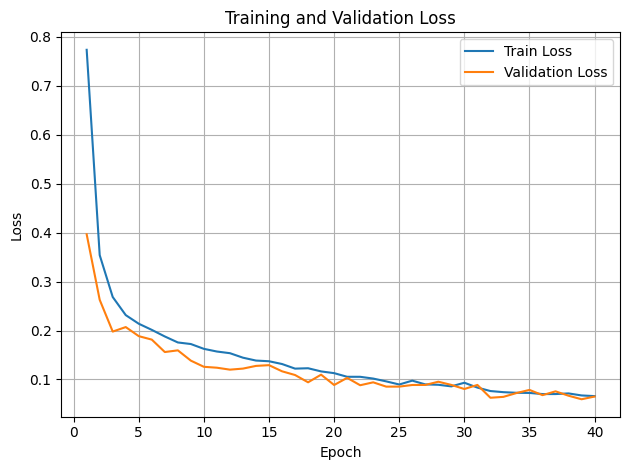

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def plot_training_loss(losses):
    losses = np.array(losses)
    train_loss = losses[:, 0]
    val_loss = losses[:, 1]
    epochs = np.arange(1, len(losses) + 1)

    plt.plot(epochs, train_loss, label="Train Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_training_loss(losses)

In [ ]:
# Beam Search, Distance
decode_single_instance(
    train_loader, gnn_model, decoder_model, decode_fn="beam", criterion="distance"
)
# Beam Search, Distance
decode_single_instance(
    train_loader, gnn_model, decoder_model, decode_fn="greedy", criterion="distance"
)

------------------------------------------------------------------------------------------
DISTANCE, BEAM:
------------------------------------------------------------------------------------------
Start node: 50
End node: 90
True path: [104, 101, 84, 20, 76, 62, 11, 42, 83, 103, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102]
True path (decoded): ['<DIST>', '<BOS>', 84, 20, 76, 62, 11, 42, 83, '<EOS>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>', '<PAD>']

Predicted path: [84, 20, 76, 62, 11, 42, 83, 55]
Target path:    [84, 20, 76, 62, 11, 42, 83]

------------------------------------------------------------------------------------------
DISTANCE, GREEDY:
------------------------------------------------------------------------------------------
Start node: 50
End node: 90
True path: [104, 101, 84, 20, 76, 62, 11, 42, 83, 103, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102, 102]
True path (decoded): ['<DIST>', '<

In [ ]:
paths_validation_beam_distance = evaluate_model_on_loader(
    gnn_model,
    decoder_model,
    test_loader,
    device,
    max_len=16,
    decoder_fn="beam",
    criterion="distance",
    print_all=False,
)
paths_validation_greedy_distance = evaluate_model_on_loader(
    gnn_model,
    decoder_model,
    test_loader,
    device,
    max_len=16,
    decoder_fn="greedy",
    criterion="distance",
    print_all=False,
)

In [ ]:
def print_path_validicity(paths):
    total = len(paths)
    correct = sum(1 for _, _, _, _, valid, _ in paths if valid)
    print(f"Path Validity: {correct}/{total} = {correct / total:.2%}")


def print_relative_path_length(paths):
    relative_lengths = [
        length
        for _, _, _, _, valid, length in paths
        if valid == True and length is not None
    ]
    if len(relative_lengths) > 0:
        avg_length = sum(relative_lengths) / len(relative_lengths)
        print(f"Average relative path length: {avg_length:.2f}")
    else:
        print("No valid paths found.")

In [ ]:
print("Distance (Beam Search and Greedy Search)")
print_path_validicity(paths_validation_beam_distance)
print_relative_path_length(paths_validation_beam_distance)
print_path_validicity(paths_validation_greedy_distance)
print_relative_path_length(paths_validation_greedy_distance)
print()

Distance (Beam Search and Greedy Search)
Path Validity: 408/542 = 75.28%
Average relative path length: 1.01
Path Validity: 477/542 = 88.01%
Average relative path length: 1.01

